### All Imports

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pylab import matrix
from scipy.fft import fft, ifft
from scipy.ndimage import gaussian_filter1d,convolve1d
from dataclasses import dataclass
from typing import Tuple, Dict
import pywt
from scipy.signal import butter, filtfilt, chirp, stft
import time
import numba as nb
from scipy import signal
import os
import tempfile
import random
from collections import Counter
from scipy.stats import norm

import shap
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist,squareform,cdist
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler, normalize

sys.path.append('/data/sswar_files/')
from PRJ_SPEC_MASTER.src.utils.spectograms_lib import *
from PRJ_SPEC_MASTER.src.utils.data_preparations import *
from PRJ_SPEC_MASTER.src.utils.noise_lib import *
from PRJ_GIS_QA.src.mowpt_dwt_cwt.synth_geophysical_waveforms import *
from PRJ_GIS_QA.src.utils.gisqa_compute_updated import *
from PRJ_GIS_QA.src.utils.plotting import *
from PRJ_GIS_QA.src.utils.helper import *

fig_save_path = '/data/sswar_files/PRJ_GIS_QA/figs/forpaper/all_results_figures/synth_geophysical_signals_application'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Utility

In [4]:
def check_disk_space_requirement(arrays:dict=None):
    print(f"{'Variable':<10} {'RAM (KB)':>12} {'Disk .npy (KB)':>16} {'Disk .npz (KB)':>16}")
    print("-" * 58)

    for name, arr in arrays.items():
        # In-memory size
        ram_kb = arr.nbytes / 1024

        # On-disk size as raw .npy
        with tempfile.NamedTemporaryFile(suffix=".npy", delete=False) as f_npy:
            np.save(f_npy, arr)
            npy_path = f_npy.name
        npy_kb = os.path.getsize(npy_path) / 1024
        os.remove(npy_path)

        # On-disk size as compressed .npz
        with tempfile.NamedTemporaryFile(suffix=".npz", delete=False) as f_npz:
            np.savez_compressed(f_npz, data=arr)
            npz_path = f_npz.name
        npz_kb = os.path.getsize(npz_path) / 1024
        os.remove(npz_path)

        print(f"{name:<10} {ram_kb:12.2f} {npy_kb:16.2f} {npz_kb:16.2f}")

def compute_stft(signal, fs):
    nperseg = int(fs * 1.28)
    noverlap = int(nperseg * 0.90)
    f, t_stft, Zxx = stft(signal, fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann', boundary='zeros')
    return np.abs(Zxx), f, t_stft

def compute_stft_linear(signal, fs):
    """STFT returning raw linear amplitude (no dB scaling)."""
    nperseg = int(fs * 2.0)
    noverlap = int(nperseg * 0.95)
    nfft = 1024
    f, t_stft, Zxx = stft(signal, fs=fs, window='blackmanharris',
                          nperseg=nperseg, noverlap=noverlap, nfft=nfft, boundary='zeros')
    return np.abs(Zxx), f, t_stft

def compute_cwt(signal, fs, n_scales=80, omega0=5.0, norm='l2'):
    """CWT with configurable L1/L2 norm."""
    n = len(signal)
    n_pad = int(2 ** np.ceil(np.log2(2 * n)))
    data_pad = np.zeros(n_pad)
    data_pad[:n] = signal
    data_fft = fft(data_pad)

    freqs = np.linspace(0.5, fs/2.0 * 0.95, n_scales)
    scales = (omega0 * fs) / (2.0 * np.pi * freqs)
    output = np.zeros((len(scales), n), dtype=complex)

    for i, scale in enumerate(scales):
        x = np.arange(n_pad) - (n_pad - 1.0) / 2.0

        # Apply strict scaling norms
        if norm == 'l1':
            scale_factor = scale
        elif norm == 'l2':
            scale_factor = np.sqrt(scale)
        else:
            raise ValueError("Norm must be 'l1' or 'l2'")

        psi = (np.pi ** -0.25) * np.exp(1j * omega0 * x / scale) * np.exp(-0.5 * (x / scale) ** 2) / scale_factor
        psi_fft = fft(np.roll(psi, -(n_pad // 2)))
        output[i, :] = ifft(data_fft * np.conj(psi_fft))[:n]

    return np.abs(output), freqs

def compute_modwt_matrix(signal, level=5, wavelet='sym4'):
    """MODWT is inherently L2 normalized by the QMF filters."""
    n = len(signal)
    mod = n % (2 ** level)
    sig_pad = np.pad(signal, (0, (2**level) - mod), mode='symmetric') if mod > 0 else signal
    swt_coeffs = pywt.swt(sig_pad, wavelet, level=level, trim_approx=True)
    return np.vstack([np.abs(c)[:n] for c in swt_coeffs])

def get_gray_order(level):
    order = [0]
    for i in range(1, level + 1):
        order = order + [2**i - 1 - x for x in order]
    return order

def upsample_filter(f, level):
    zeros = 2**(level - 1) - 1
    if zeros == 0: return np.array(f)
    up = np.zeros(len(f) + (len(f) - 1) * zeros)
    up[::zeros + 1] = f
    return up

def compute_mowpt_matrix(signal, level=5, wavelet='sym4', norm='l2'):
    """MOWPT with configurable L1/L2 norm."""
    wavelet_obj = pywt.Wavelet(wavelet)
    h = np.array(wavelet_obj.dec_lo) / np.sqrt(2)
    g = np.array(wavelet_obj.dec_hi) / np.sqrt(2)

    nodes = [signal]
    for j in range(1, level + 1):
        h_up = upsample_filter(h, j)
        g_up = upsample_filter(g, j)

        next_nodes = []
        for node in nodes:
            approx = convolve1d(node, h_up, mode='wrap', origin=0)
            detail = convolve1d(node, g_up, mode='wrap', origin=0)
            next_nodes.extend([approx, detail])
        nodes = next_nodes

    freq_order = get_gray_order(level)
    matrix = np.vstack([np.abs(nodes[i]) for i in freq_order])

    if norm == 'l1':
        matrix *= (2 ** (level / 2.0))

    return matrix

@nb.njit(fastmath=True)
def atrous_circular_convolve(x, h, step):
    """
    Numba JIT compiled periodic circular convolution using the 'à trous'
    stride algorithm. Bypasses zero-padding for massive speedup.
    """
    N = len(x)
    K = len(h)
    out = np.zeros(N)
    for i in range(N):
        val = 0.0
        for j in range(K):
            # Circular boundary condition with dynamic stride
            idx = (i - j * step) % N
            val += x[idx] * h[j]
        out[i] = val
    return out

def compute_mowpt_jit(signal, level=5, wavelet='sym4', norm='l2'):
    """MOWPT utilizing JIT-compiled à trous algorithm."""
    wavelet_obj = pywt.Wavelet(wavelet)
    h = np.array(wavelet_obj.dec_lo) / np.sqrt(2)
    g = np.array(wavelet_obj.dec_hi) / np.sqrt(2)

    nodes = [signal]
    for j in range(1, level + 1):
        step = 2 ** (j - 1)
        next_nodes = []
        for node in nodes:
            approx = atrous_circular_convolve(node, h, step)
            detail = atrous_circular_convolve(node, g, step)
            next_nodes.extend([approx, detail])
        nodes = next_nodes

    freq_order = get_gray_order(level)
    matrix = np.vstack([np.abs(nodes[i]) for i in freq_order])

    if norm == 'l1':
        matrix *= (2 ** (level / 2.0))
    
    # Return raw linear coefficients
    return matrix

def generate_and_plot_variants(N=5, isplot=True):
    
    # 6 waveform types
    waveform_types = [
        'impulsive_earthquake',
        'volcanic_tornillo',
        'surface_wave_dispersion',
        't_phase_earthquake',
        'strombolian_explosion',
        'hybrid_eruption'
    ]
    
    waveform_catalog = {waveform: [] for waveform in waveform_types}

    fig, axes = plt.subplots(len(waveform_types), N, figsize=(4 * N, 3 * len(waveform_types)), sharex=True)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    

    for row_idx, wave_type in enumerate(waveform_types):
        for col_idx in range(N):
            # new seed for each variant to ensure randomness
            seed = int(time.time() * 1000) % 100000 + (row_idx * N + col_idx) * 123
            synth = AdvancedSeismicSyntheticsParams(seed=seed)
            
            # Randomized parameters based on the specific waveform
            if wave_type == 'impulsive_earthquake':
                p_onset = np.clip(np.random.normal(15.0, 2.0), 5.0, 20.0)
                s_onset = np.clip(p_onset + np.random.normal(7.0, 2.0), p_onset + 2.0, 40.0)
                sig, title = synth.impulsive_earthquake(
                    p_onset=p_onset,
                    p_dur=np.random.uniform(2.0, 5.0),
                    p_freq=np.random.uniform(8.0, 15.0),
                    p_decay=np.random.uniform(1.0, 3.0),
                    p_amp=np.random.uniform(0.3, 0.8),
                    s_onset=s_onset,
                    s_dur=np.random.uniform(5.0, 12.0),
                    s_freq=np.random.uniform(2.0, 6.0),
                    s_decay=np.random.uniform(0.5, 1.5),
                    s_amp=np.random.uniform(0.7, 1.5),
                    #noise_level=0.25
                )
            elif wave_type == 'volcanic_tornillo':
                sig, title = synth.volcanic_tornillo(
                    onset=np.random.uniform(5.0, 20.0),
                    freq=np.random.uniform(1.5, 4.0),
                    decay=np.random.uniform(0.04, 0.15),
                    amp=np.random.uniform(0.5, 1.5),
                    #noise_level=0.25
                )
            elif wave_type == 'surface_wave_dispersion':
                start = np.random.uniform(5.0, 15.0)
                end = np.random.uniform(40.0, 55.0)
                sig, title = synth.surface_wave_dispersion(
                    start=start,
                    end=end,
                    f0=np.random.uniform(0.2, 0.8),
                    f1=np.random.uniform(5.0, 12.0),
                    amp=np.random.uniform(0.5, 1.5),
                    #noise_level=0.25
                )
            elif wave_type == 't_phase_earthquake':
                sig, title = synth.t_phase_earthquake(
                    envelope_center=np.random.uniform(20.0, 40.0),
                    envelope_width=np.random.uniform(5.0, 15.0),
                    hf_low=np.random.uniform(2.0, 5.0),
                    hf_high=np.random.uniform(10.0, 20.0),
                    amp=np.random.uniform(1.0, 3.0),
                    #noise_level=0.25
                )
            elif wave_type == 'strombolian_explosion':
                sig, title = synth.strombolian_explosion(
                    onset=np.random.uniform(10.0, 30.0),
                    decay=np.random.uniform(1.5, 4.0),
                    amp=np.random.uniform(1.0, 2.5),
                    #noise_level=0.25
                )
            elif wave_type == 'hybrid_eruption':
                sig, title = synth.hybrid_eruption2(
                    tremor_freq=np.random.uniform(1.5, 5.0),
                    tremor_amp=np.random.uniform(0.2, 0.7),
                    exp_onset=np.random.uniform(15.0, 35.0),
                    exp_decay=np.random.uniform(1.5, 4.0),
                    exp_amp=np.random.uniform(1.0, 3.0),
                    #noise_level=0.25
                )
            
            waveform_catalog[wave_type].append([synth.t, sig])
            ax = axes[row_idx, col_idx]
            ax.plot(synth.t, sig, color='black', linewidth=0.8)
            if col_idx == 0:
                ax.set_ylabel(title, fontsize=12, fontweight='bold')
            if row_idx == 0:
                ax.set_title(f"Variant {col_idx+1}", fontsize=12)
            if row_idx == len(waveform_types) - 1:
                ax.set_xlabel("Time (s)")
            ax.grid(True, linestyle='--', alpha=0.6)
            
    if isplot:
        plt.suptitle(f"Randomized Variants of Advanced Seismic Synthetics", fontsize=16, y=0.92)
        plt.show()
    else:
        plt.close()
    
    return waveform_catalog


### Generate Random Geophysical Signals

In [7]:
#waveform_catalog = generate_and_plot_variants(N=25, isplot=False)
#np.save(os.path.join("PRJ_GIS_QA/data/forpaper/synth_geophysical_signals_application", "synth_geophysical_waveform_catalog.npy"), waveform_catalog)

waveform_catalog_path = '/data/sswar_files/PRJ_GIS_QA/data/forpaper_V0/synth_geophysical_signals_application/synth_geophysical_waveform_catalog.npy'
if os.path.exists(waveform_catalog_path):
    print('loading from existing dataset...')
    waveform_catalog = np.load(waveform_catalog_path, allow_pickle=True)
    waveform_catalog = waveform_catalog.item()
else:
    print('generating dataset...')
    waveform_catalog = generate_and_plot_variants(N=25, isplot=False)
    #np.save(waveform_catalog_path, waveform_catalog)

loading from existing dataset...


In [8]:
waveform_catalog_modwt = {}
list_images = []
list_names = []
list_ts = []
list_stft_vals = []
for key, signals in waveform_catalog.items():
    for i, (tsig, sig) in enumerate(signals):
        #freqscwt, tcwt, cwt, _ = cwt_simple(signal=sig, sr=100, fscale={'start':1, 'end':64, 'num':1}, wavelet="morl", fscaletype='linear',
        #                                    vmin_percentile=0, vmax_percentile=100, f_min=0, f_max=50, max_normalize=True, powerlog=False, decimate_factor=None)
        cwt, freqscwt = compute_cwt(sig, fs=100.0, n_scales=32, norm='l2')
        list_images.append(cwt)
        list_names.append(f"{key}_sample{i}")
        list_ts.append(sig)
    list_stft_vals.append(freqscwt)

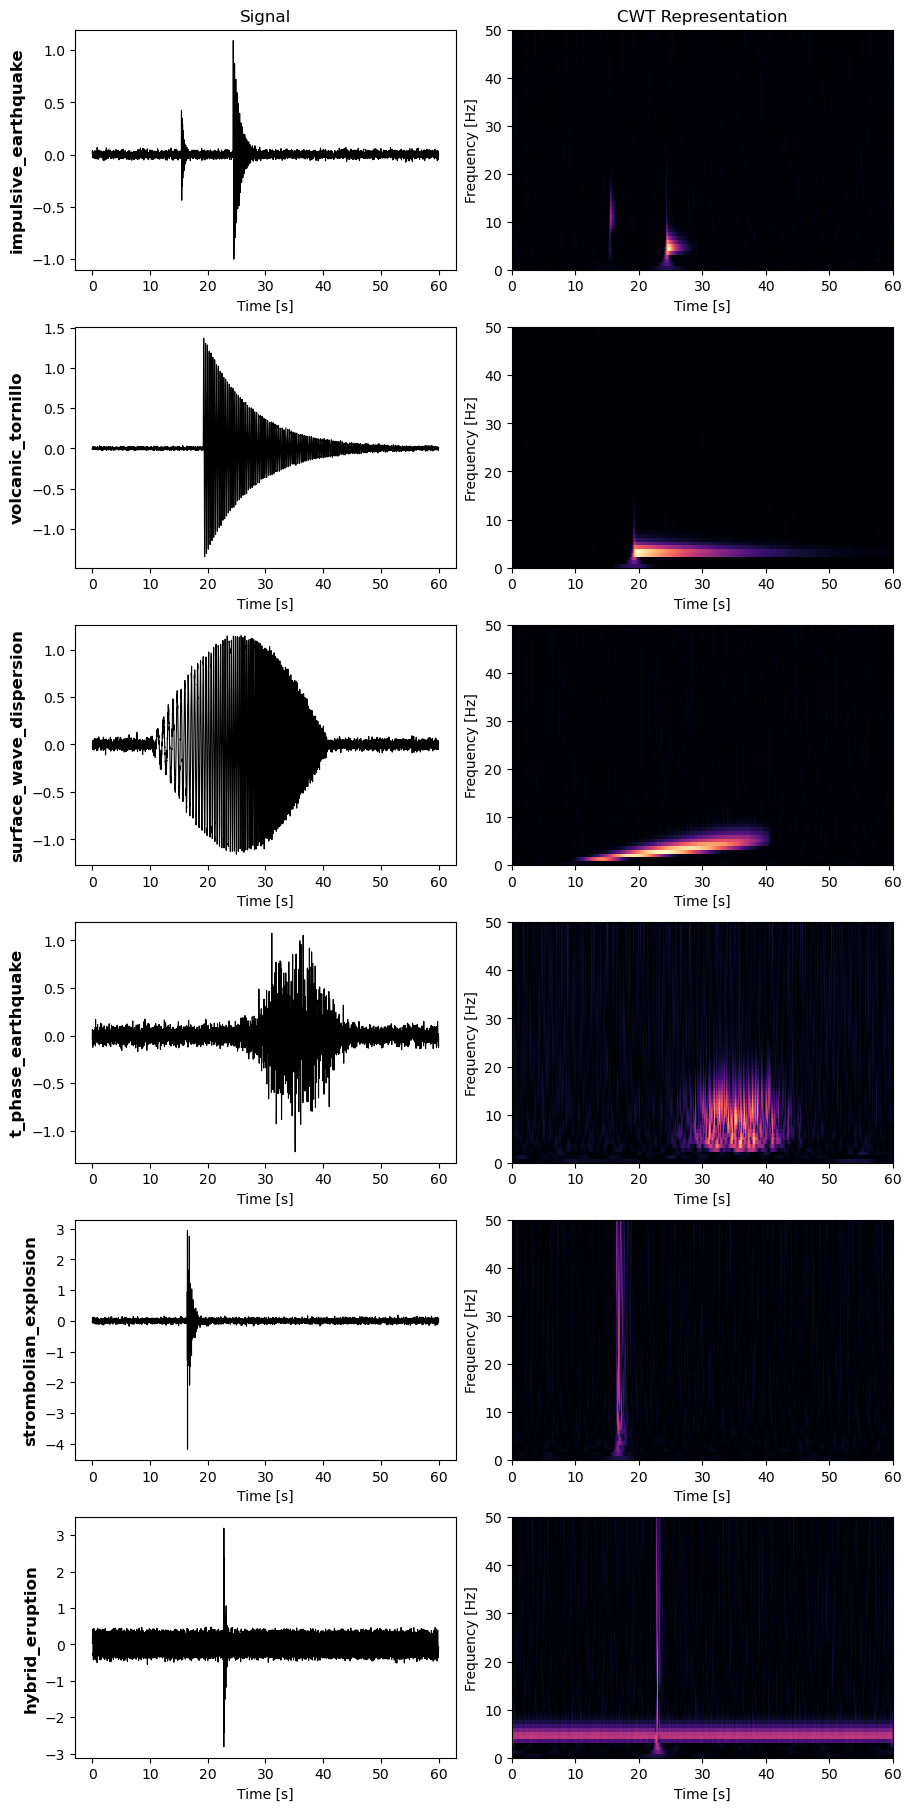

In [9]:
keys = list(waveform_catalog.keys())
n_keys = len(keys)
n_samples = 1

# 2 columns per sample (Signal + CWT)
fig, axes = plt.subplots(n_keys, n_samples * 2, figsize=(9, 3 * n_keys), constrained_layout=True)

for i, key in enumerate(keys):
    # Randomly select 3 indices from the available elements
    selected_indices = random.sample(range(len(waveform_catalog[key])), n_samples)
    
    for j, idx in enumerate(selected_indices):
        time_series, signal = waveform_catalog[key][idx]
        # Compute CWT
        scales = np.arange(1, 128)
        coef, _ = compute_cwt(signal, fs=100.0, n_scales=64, norm='l2')
        
        # Handle indexing for subplots
        ax_sig = axes[i, j * 2] if n_keys > 1 else axes[j * 2]
        ax_cwt = axes[i, j * 2 + 1] if n_keys > 1 else axes[j * 2 + 1]
        
        # Plot Signal
        ax_sig.plot(time_series, signal, color='black', linewidth=0.8)
        if j ==0:
            ax_sig.set_ylabel(key, fontsize=12, fontweight='bold')
        
        # Plot CWT
        ax_cwt.imshow(np.log1p(coef), aspect='auto', origin='lower', extent=[0,60,0,50], cmap='magma', interpolation='none')
        
        if i == 0:
            ax_sig.set_title(f"Signal")
            ax_cwt.set_title(f"CWT Representation")

        ax_sig.set_xlabel('Time [s]')
        ax_cwt.set_xlabel('Time [s]')
        ax_cwt.set_ylabel('Frequency [Hz]')

#fig.savefig(os.path.join(fig_save_path,'raw_synth_signal_types.svg'),dpi=300)
plt.show()

In [10]:
list_images[0].shape

(32, 6000)

### Generate Spec2Vec Metrics on the Signals

In [11]:
sel_columns = [
       'permutation_entropy_antropy', 
       'spectral_entropy_antropy',
       'svd_entropy_antropy', 
       'petrosian_fd_antropy', 
       'detrended_fluctuation_antropy', 
       'hjorth_mobility_antropy',
       'hjorth_complexity_antropy', 
       'higuchi_fd_antropy',
       'normalized_permutation_entropy_ordpy',
       'statistical_complexity_entropy_ordpy', 
       'fisher_shannon_ordpy',
       'global_node_entropy_ordpy', 
       'renyi_complexity_entropy_long_ordpy',
       'renyi_stat_complexity_long_ordpy',
       'tsallis_complexity_entropy_long_ordpy',
       'tsallis_stat_complexity_long_ordpy',
       'weighted_permutation_entropy_ordpy', 
       'missing_links_ordpy',
       'Absolute energy',
       'Average power',
       'Kurtosis', 'Lempel-Ziv complexity', 'Mean','Median','Skewness', 'Standard deviation',
       '75th_percentile',
       '25th_percentile',
       'label']

In [ ]:
if os.path.exists("/data/sswar_files/PRJ_GIS_QA/data/forpaper_V0/synth_geophysical_signals_application/spec2vec_synth_geophysical_signals.csv"):
    spec_pointwise_metrics_df = pd.read_csv("/data/sswar_files/PRJ_GIS_QA/data/forpaper_V0/synth_geophysical_signals_application/spec2vec_synth_geophysical_signals.csv", index=None)
else:
    giq = GISQAPipeline()
    spec_pointwise_metrics_df = giq.compute_pointwise_metrics_from_spec(list_names, list_images, 
                                                                        is_hilbertize = 1,
                                                                        is_normalize_stat = 0,
                                                                        is_normalize_entropy = 0,
                                                                        is_best_features = 0,
                                                                        ordpydx = 6, antropydx = 6,
                                                                        metrics_list=sel_columns, hilbert_locs=None)
    spec_pointwise_metrics_df_copy.to_csv("/data/sswar_files/PRJ_GIS_QA/data/forpaper_V0/synth_geophysical_signals_application/spec2vec_synth_geophysical_signals.csv", index=None)


1 number of row processed
51 number of row processed
101 number of row processed


In [ ]:
# Create a copy of the existing dataframe
if os.path.exists("/data/sswar_files/PRJ_GIS_QA/data/forpaper_V0/synth_geophysical_signals_application/spec2vec_synth_geophysical_signals2.csv"):
    spec_pointwise_metrics_df = pd.read_csv("/data/sswar_files/PRJ_GIS_QA/data/forpaper_V0/synth_geophysical_signals_application/spec2vec_synth_geophysical_signals_copy.csv", index=None)
else:
    spec_pointwise_metrics_df_copy = spec_pointwise_metrics_df.copy()

    features_list = [clusterimages(img, ncomp=5, isplot=0, image_thresh=80) for img, name in zip(list_images, list_names)]
    all_features_df = pd.concat(features_list, ignore_index=True)
    spec_pointwise_metrics_df_copy = pd.concat([spec_pointwise_metrics_df_copy, all_features_df], axis=1)

    spec_pointwise_metrics_df_copy.to_csv("/data/sswar_files/PRJ_GIS_QA/data/forpaper_V0/synth_geophysical_signals_application/spec2vec_synth_geophysical_signals_copy.csv", index=None)


### Applying Clustering on Texture+Stat Columns

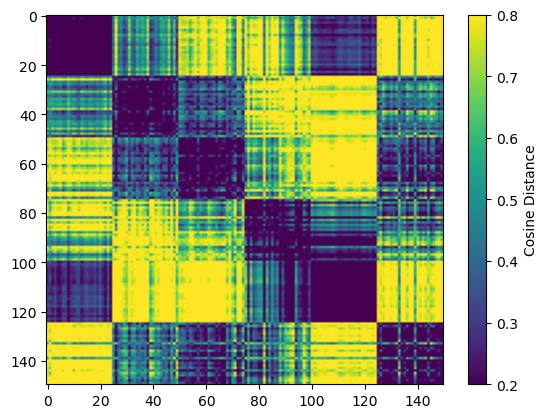

In [62]:
# Transpose features to compute cosine distance between columns (features) instead of rows (samples) if needed
features = spec_pointwise_metrics_df.drop(columns=['label']).values

scaler = StandardScaler()
#scaler = RobustScaler()
features= scaler.fit_transform(features)

cos_dist = cdist(features, features, metric='cosine')
cos_dist = cos_dist/np.max(cos_dist)

plt.imshow(cos_dist, cmap='viridis', aspect='auto', vmin=0.2, vmax=0.8)
plt.colorbar(label='Cosine Distance')

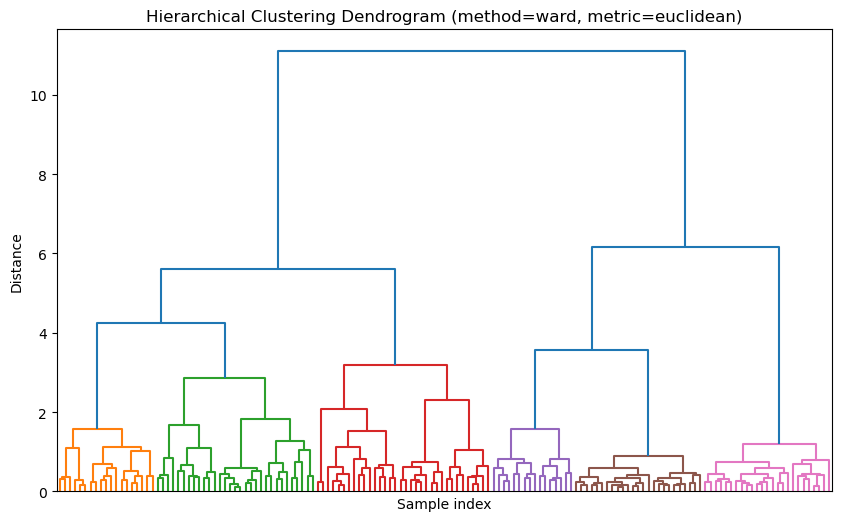

Total Labels:  150


In [64]:
def perform_hierarchical_clustering(data, method='ward', metric='euclidean', plot_dendrogram=True, color_threshold=None, figsize=(10, 6), savefig=False, savepath=None):
    #distance_matrix = cdist(data, data, metric=metric) #pdist(data, metric=metric)
    distance_matrix = pdist(data, metric=metric)
    linkage_matrix = linkage(distance_matrix, method=method,optimal_ordering=True)

    if plot_dendrogram:
        plt.figure(figsize=figsize)
        dendro = dendrogram(linkage_matrix, color_threshold=color_threshold, no_labels=True)            
        plt.title(f'Hierarchical Clustering Dendrogram (method={method}, metric={metric})')
        plt.xlabel('Sample index')
        plt.ylabel('Distance')
        if savefig:
            plt.savefig(savepath, dpi=300)
        plt.show()

    return linkage_matrix #dendro['leaves'], dendro['leaves_color_list'], dendro['color_list']

def merge_clusters(linkage_matrix, num_clusters=None, distance_threshold=None):
    if num_clusters is not None:
        labels = fcluster(linkage_matrix, t=num_clusters, criterion='maxclust')
    elif distance_threshold is not None:
        labels = fcluster(linkage_matrix, t=distance_threshold, criterion='distance')
    else:
        raise ValueError("You must provide either 'num_clusters' or 'distance_threshold'")
    return labels

col_theshold = 3.5
dist_threshold = 3.5
features = spec_pointwise_metrics_df.drop(columns=['label']).values

scaler = StandardScaler()
features= scaler.fit_transform(features)
features = normalize(features, norm='l2')

linkage_matrix = perform_hierarchical_clustering(features,method='ward',metric='euclidean',
                                                plot_dendrogram=True,color_threshold=col_theshold)
#hir_labels = merge_clusters(linkage_matrix, distance_threshold=dist_threshold)
hir_labels = merge_clusters(linkage_matrix, num_clusters=6)
print('Total Labels: ', len(hir_labels))

In [65]:
Counter(hir_labels)

Counter({np.int32(3): 34,
         np.int32(2): 31,
         np.int32(6): 25,
         np.int32(5): 25,
         np.int32(1): 19,
         np.int32(4): 16})

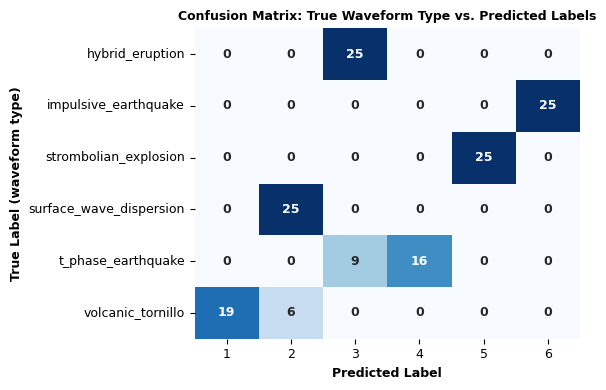

In [66]:
label_map = pd.DataFrame({'labels':hir_labels, 'waveform_type':['_'.join(name.split('_')[:-1]) for name in list_names]})
label_map.sort_values(by='labels',inplace=True)
label_map = label_map.reset_index(drop=True)

cm = pd.crosstab(label_map['waveform_type'], label_map['labels'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 9, 'fontweight':'bold'}, cbar=False)
plt.title('Confusion Matrix: True Waveform Type vs. Predicted Labels', fontsize=9, fontweight='bold')
plt.ylabel('True Label (waveform type)',fontsize=9, fontweight='bold')
plt.xlabel('Predicted Label',fontsize=9, fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [67]:
score = silhouette_score(features, hir_labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3585


[100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124]
Looking at Sample:  116


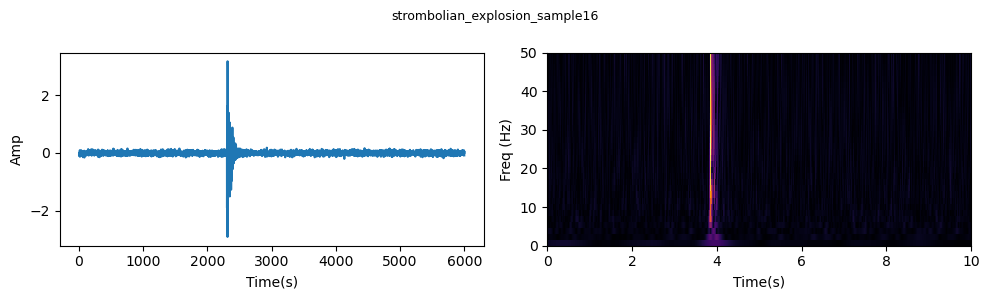

In [68]:
target_class = 5
target_idxs = np.where(hir_labels==target_class)[0]
print(target_idxs)
target_idx = random.choice(target_idxs)
print('Looking at Sample: ', target_idx)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(list_ts[target_idx]); plt.xlabel('Time(s)'); plt.ylabel('Amp')
plt.subplot(1,2,2);plt.imshow(np.log1p(list_images[target_idx]), aspect='auto', extent = [0, 10, 0, 50],
                                        origin = 'lower', cmap='inferno', interpolation='none')
plt.xlabel('Time(s)'); plt.ylabel('Freq (Hz)')
plt.suptitle(list_names[target_idx], fontsize=9)
plt.tight_layout()
plt.show()


### Applying Clustering Texture+Text+Spatial Columns

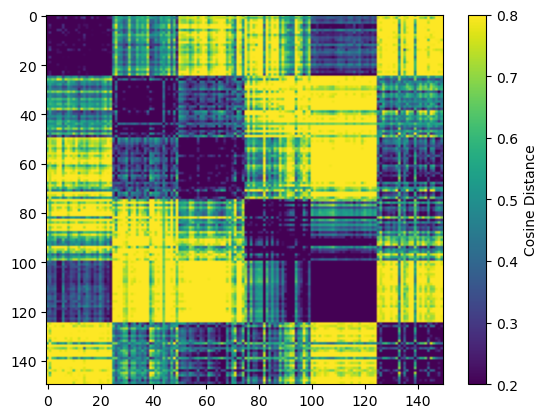

In [69]:
# Transpose features to compute cosine distance between columns (features) instead of rows (samples) if needed
features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values

scaler = StandardScaler()
#scaler = RobustScaler()
features= scaler.fit_transform(features)

cos_dist = cdist(features, features, metric='cosine')
cos_dist = cos_dist/np.max(cos_dist) 

plt.imshow(cos_dist, cmap='viridis', aspect='auto', vmin=0.2, vmax=0.8)
plt.colorbar(label='Cosine Distance')
plt.show()

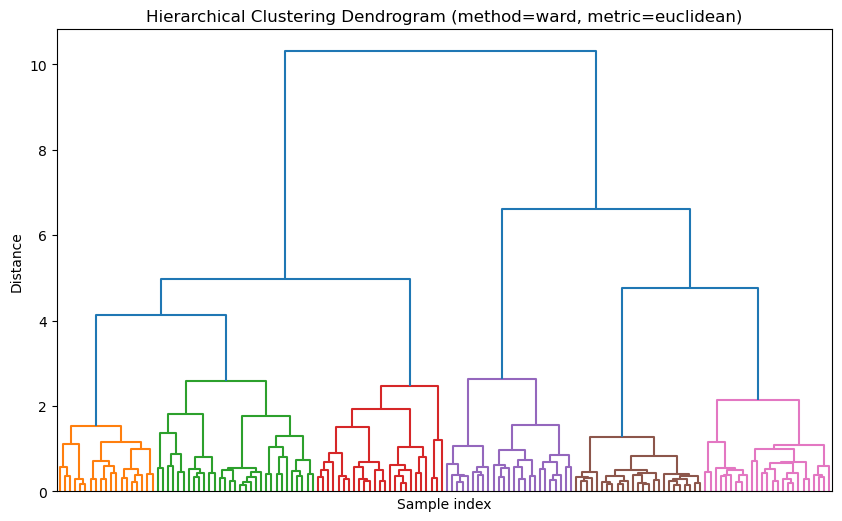

Total Labels:  150


In [ ]:
sel_colums = ['svd_entropy_antropy', 'detrended_fluctuation_antropy', 
              #'statistical_complexity_entropy_ordpy','higuchi_fd_antropy',
              'hjorth_complexity_antropy', 
              'weighted_permutation_entropy_ordpy', '25th_percentile','label']

col_theshold = 3.5#2.6#
dist_threshold = 3.5#2.6#
features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values

scaler = StandardScaler()
#scaler = RobustScaler()
features= scaler.fit_transform(features)
features = normalize(features, norm='l2')

linkage_matrix = perform_hierarchical_clustering(features, method='ward',metric='euclidean',
                                                plot_dendrogram=True,color_threshold=col_theshold, savepath=None)#savefig=100,os.path.join(fig_save_path,'dendrogram_results.svg')
hir_labels = merge_clusters(linkage_matrix, distance_threshold=dist_threshold)
print('Total Labels: ', len(hir_labels))

In [71]:
Counter(hir_labels)

Counter({np.int32(2): 31,
         np.int32(6): 25,
         np.int32(4): 25,
         np.int32(5): 25,
         np.int32(3): 25,
         np.int32(1): 19})

In [72]:
hir_labels

array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

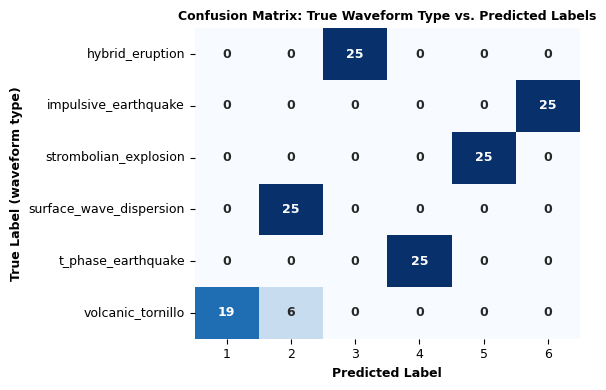

In [ ]:
label_map = pd.DataFrame({'labels':hir_labels, 'waveform_type':['_'.join(name.split('_')[:-1]) for name in list_names]})
label_map.sort_values(by='labels',inplace=True)
label_map = label_map.reset_index(drop=True)

cm = pd.crosstab(label_map['waveform_type'], label_map['labels'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 9, 'fontweight':'bold'}, cbar=False)
plt.title('Confusion Matrix: True Waveform Type vs. Predicted Labels', fontsize=9, fontweight='bold')
plt.ylabel('True Label (waveform type)',fontsize=9, fontweight='bold')
plt.xlabel('Predicted Label',fontsize=9, fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
#plt.savefig(os.path.join(fig_save_path,'confusion_matrix.svg'), dpi=300)
plt.show()

In [74]:
score = silhouette_score(features, hir_labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3357


[25 26 35 44 46 48 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67
 68 69 70 71 72 73 74]
Looking at Sample:  66


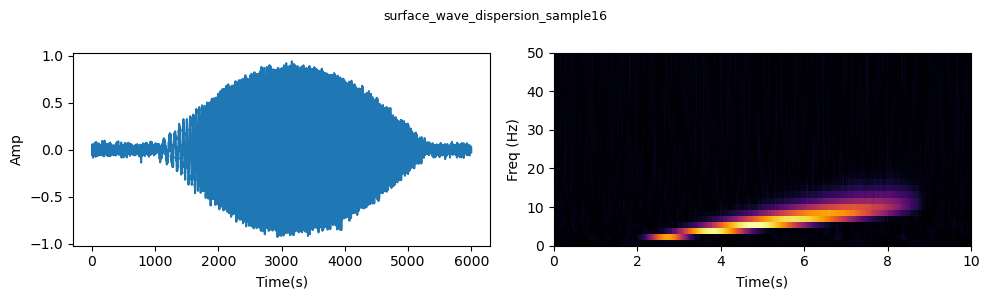

In [75]:
target_class = 2
target_idxs = np.where(hir_labels==target_class)[0]
print(target_idxs)
target_idx = random.choice(target_idxs)
print('Looking at Sample: ', target_idx)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(list_ts[target_idx]); plt.xlabel('Time(s)'); plt.ylabel('Amp')
plt.subplot(1,2,2);plt.imshow(np.log1p(list_images[target_idx]), aspect='auto', extent = [0, 10, 0, 50],
                                        origin = 'lower', cmap='inferno', interpolation='none')
plt.xlabel('Time(s)'); plt.ylabel('Freq (Hz)')
plt.suptitle(list_names[target_idx], fontsize=9)
plt.tight_layout()
plt.show()


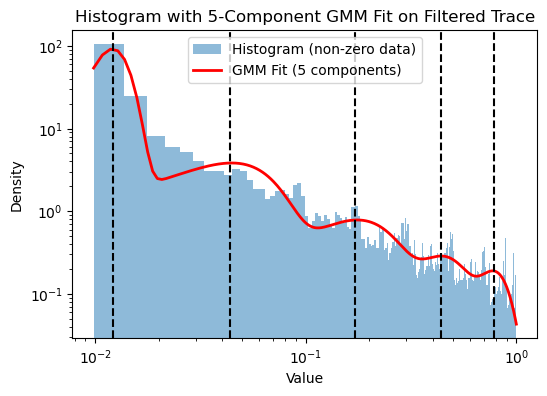

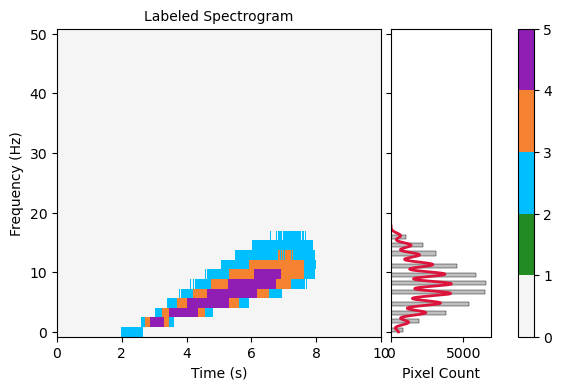

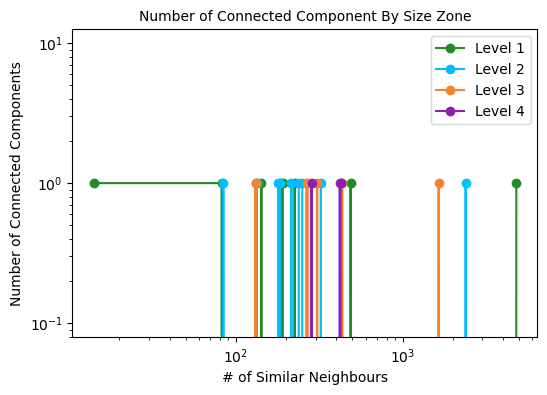

,SmallAreaEmphasis,LargeAreaEmphasis,GrayLevelNonUniformityNormalized,SizeZoneNonUniformityNormalized,LargeAreaHighGrayLevelEmphasis,WeightedZoneSizePercentageFeatureValue
0,0.000218,1.227211e+06,0.294925,0.039781,3.052469e+06,0.02619


In [99]:
clusterimages(list_images[target_idx], ncomp=5, isplot=1, image_thresh=80, ts=np.linspace(0,10,list_images[0].shape[1]), freqs=np.linspace(0,50,list_images[0].shape[0]))

### Checking for the Feature Interpretability

/tmp/ipykernel_927737/1405642382.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')


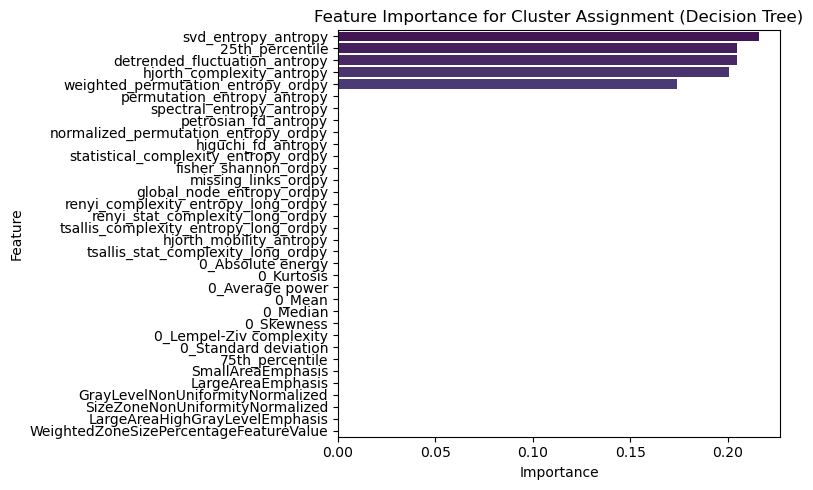

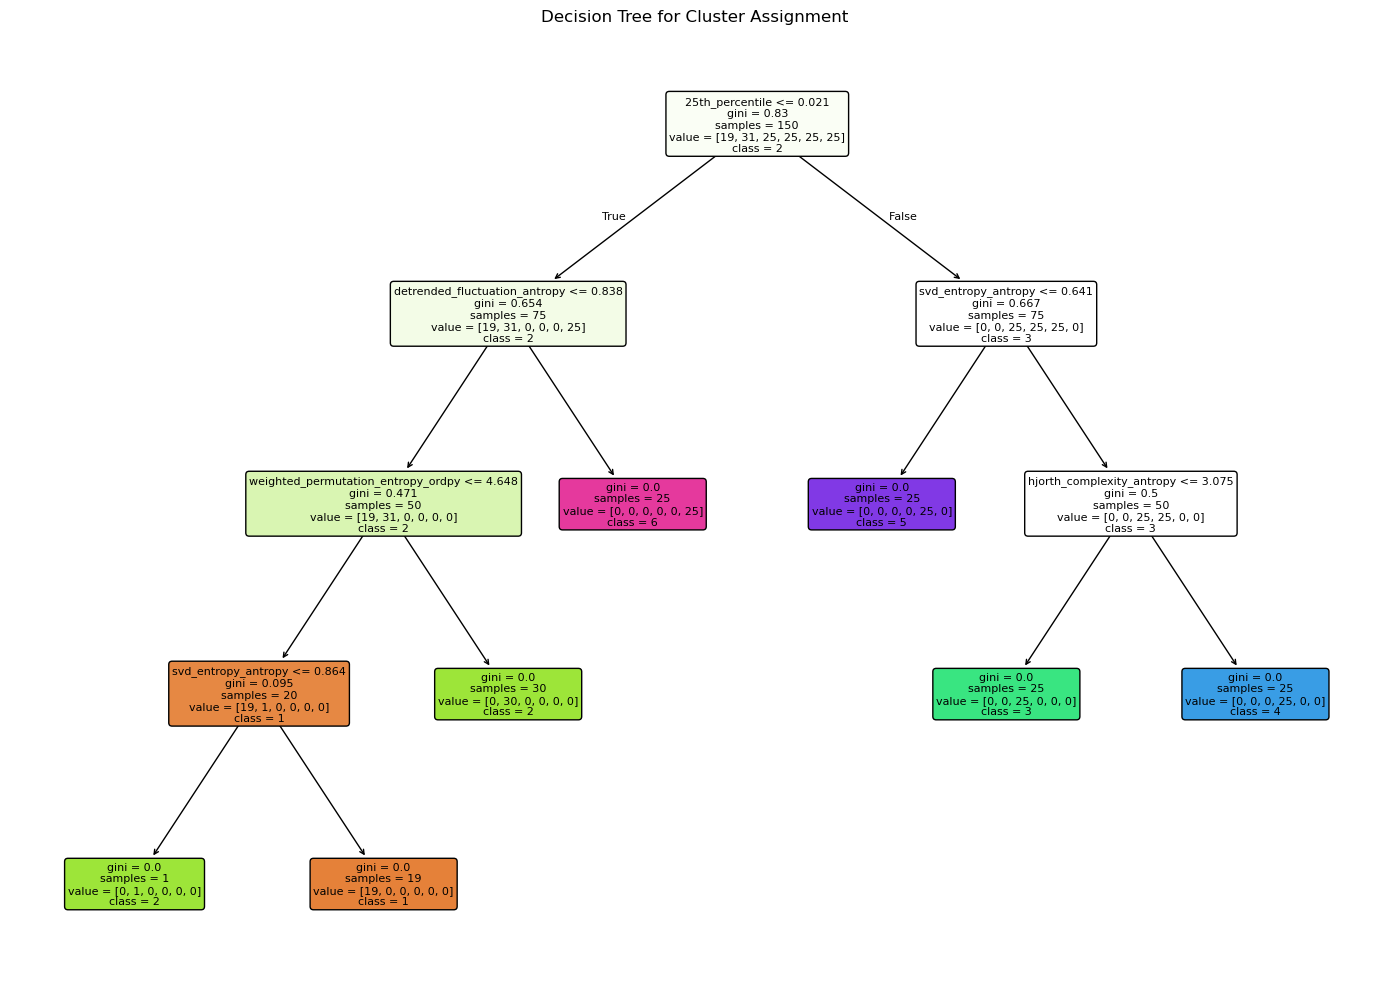

Decision Tree Rules:
 |--- 25th_percentile <= 0.02
|   |--- detrended_fluctuation_antropy <= 0.84
|   |   |--- weighted_permutation_entropy_ordpy <= 4.65
|   |   |   |--- svd_entropy_antropy <= 0.86
|   |   |   |   |--- class: 2
|   |   |   |--- svd_entropy_antropy >  0.86
|   |   |   |   |--- class: 1
|   |   |--- weighted_permutation_entropy_ordpy >  4.65
|   |   |   |--- class: 2
|   |--- detrended_fluctuation_antropy >  0.84
|   |   |--- class: 6
|--- 25th_percentile >  0.02
|   |--- svd_entropy_antropy <= 0.64
|   |   |--- class: 5
|   |--- svd_entropy_antropy >  0.64
|   |   |--- hjorth_complexity_antropy <= 3.08
|   |   |   |--- class: 3
|   |   |--- hjorth_complexity_antropy >  3.08
|   |   |   |--- class: 4



In [220]:
# Analyze feature interpretability using Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns

# Prepare features and labels
features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values
feature_names = list(spec_pointwise_metrics_df_copy.drop(columns=['label']).columns)
labels = hir_labels

#scaler = StandardScaler()
#scaler = RobustScaler()
#features= scaler.fit_transform(features)
#features = normalize(features, norm='l2')

# Fit Decision Tree
clf = DecisionTreeClassifier(max_depth=6, random_state=42)
clf.fit(features, labels)

# Feature importance
importances = clf.feature_importances_
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
plt.title('Feature Importance for Cluster Assignment (Decision Tree)')
plt.tight_layout()
plt.show()

# Visualize the tree structure
plt.figure(figsize=(14, 10))
plot_tree(clf, feature_names=feature_names, class_names=[str(c) for c in np.unique(labels)], filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree for Cluster Assignment')
plt.tight_layout()
plt.show()

# Print top rules
from sklearn.tree import export_text
rules = export_text(clf, feature_names=feature_names)
print('Decision Tree Rules:\n', rules)

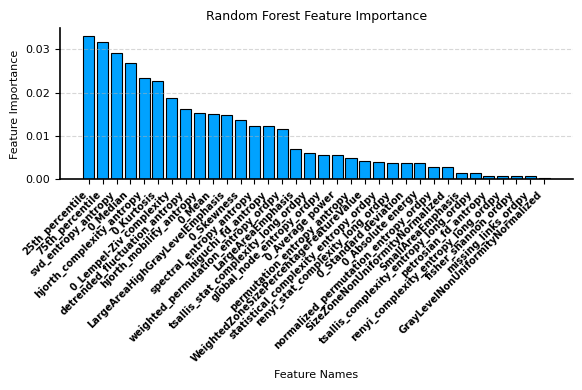

In [276]:
features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values
feature_names = list(spec_pointwise_metrics_df_copy.drop(columns=['label']).columns)

#scaler = StandardScaler()
#features= scaler.fit_transform(features)
#features = normalize(features, norm='l2')

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(features, hir_labels)

shap.initjs()
explainer = shap.TreeExplainer(rf_clf)
shap_values_stat = explainer(features)
_, feature_imp_df = HelperFunc.print_feature_importances_shap_values(shap_values_stat, feature_names)

plt.figure(figsize=(6, 4))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.bar(feature_imp_df['index'], feature_imp_df['vals'], color="#00A2FF", edgecolor='black', linewidth=0.8)
plt.xlabel('Feature Names',fontsize=8); plt.ylabel('Feature Importance',fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=7, fontweight='bold'); plt.yticks(fontsize=8)
plt.title('Random Forest Feature Importance', fontsize=9)
plt.tight_layout()
plt.show()

In [313]:
import matplotlib
from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version
from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version
#result = permutation_importance(clf, features, hir_labels, n_repeats=20, random_state=42)

def plot_permutation_importance(clf, X, y, feature_names, ax):
    result = permutation_importance(clf, X, y, n_repeats=25, random_state=42, n_jobs=2)
    perm_sorted_idx = result.importances_mean.argsort()

    # `labels` argument in boxplot is deprecated in matplotlib 3.9 and has been
    # renamed to `tick_labels`. The following code handles this, but as a
    # scikit-learn user you probably can write simpler code by using `labels=...`
    # (matplotlib < 3.9) or `tick_labels=...` (matplotlib >= 3.9).
    tick_labels_parameter_name = (
        "tick_labels"
        if parse_version(matplotlib.__version__) >= parse_version("3.9")
        else "labels"
    )
    tick_labels_dict = {tick_labels_parameter_name: np.array(feature_names)[perm_sorted_idx]}
    ax.boxplot(result.importances[perm_sorted_idx].T, vert=False, **tick_labels_dict)
    ax.axvline(x=0, color="k", linestyle="--")
    ax.figure.tight_layout()

    return ax

In [280]:
# fig, ax1 = plt.subplots(1,1,figsize=(8, 6))
# plot_permutation_importance(rf_clf, features, hir_labels, feature_names, ax1)
# ax1.set_title("Perm. Imp. on subset of features (test set)")
# ax1.set_xlabel("Decrease in accuracy score")
# ax1.figure.tight_layout()

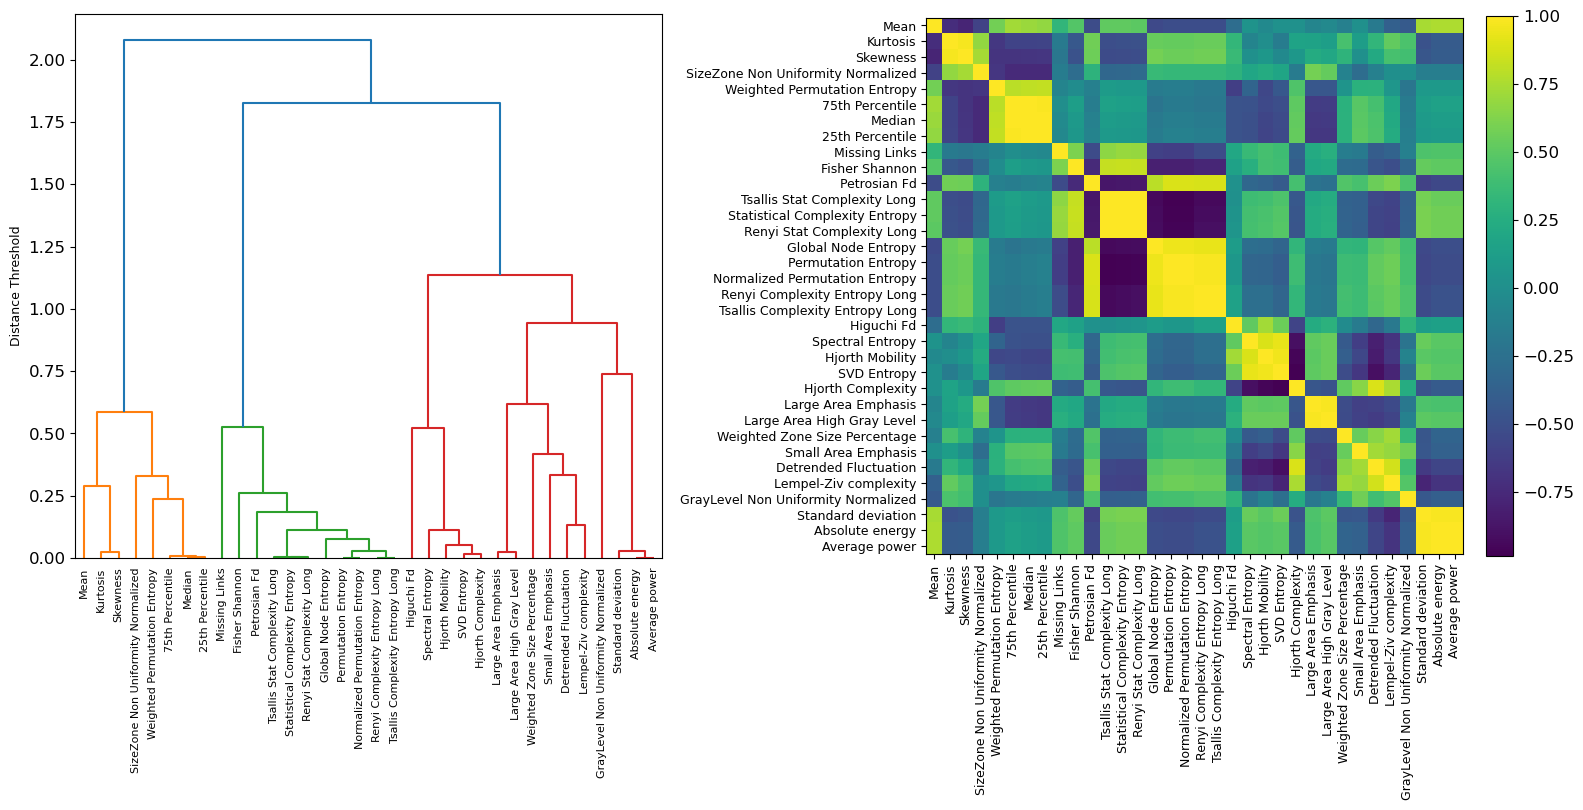

In [322]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values
feature_names = list(spec_pointwise_metrics_df_copy.drop(columns=['label']).columns)
feature_names_print = ['Permutation Entropy', 'Spectral Entropy', 'SVD Entropy', 'Hjorth Mobility',
'Hjorth Complexity', 'Petrosian Fd', 'Higuchi Fd', 'Detrended Fluctuation',
'Normalized Permutation Entropy', 'Statistical Complexity Entropy', 'Fisher Shannon', 'Global Node Entropy',
'Missing Links','Renyi Complexity Entropy Long', 'Renyi Stat Complexity Long', 'Tsallis Complexity Entropy Long', 'Tsallis Stat Complexity Long', 
'Weighted Permutation Entropy', 'Absolute energy','Average power','Kurtosis','Lempel-Ziv complexity',
'Mean','Median','Skewness','Standard deviation','75th Percentile','25th Percentile',
'Small Area Emphasis','Large Area Emphasis','GrayLevel Non Uniformity Normalized','SizeZone Non Uniformity Normalized',
'Large Area High Gray Level','Weighted Zone Size Percentage']

scaler = StandardScaler()
features = scaler.fit_transform(features)
features = normalize(features, norm='l2')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

corr = spearmanr(features).correlation
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)

# We convert the correlation matrix to a distance matrix before performing
# hierarchical clustering using Ward's linkage.
distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))

dendro = hierarchy.dendrogram(
    dist_linkage, labels=feature_names_print, ax=ax1, leaf_rotation=90
)
dendro_idx = np.arange(0, len(dendro["ivl"]))
ax1.set_ylabel('Distance Threshold', fontsize=9)

ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]])
ax2.set_xticks(dendro_idx)
ax2.set_yticks(dendro_idx)
ax2.set_xticklabels(dendro["ivl"], rotation="vertical", fontsize=9)
ax2.set_yticklabels(dendro["ivl"], fontsize=9)
plt.colorbar(ax2.images[0], ax=ax2, orientation='vertical', fraction=0.046, pad=0.04)
_ = fig.tight_layout()
plt.savefig(os.path.join(fig_save_path,'column_correlation_analysis.svg'), dpi=300)

In [415]:
from collections import defaultdict

features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values
feature_names = list(spec_pointwise_metrics_df_copy.drop(columns=['label']).columns)

cluster_ids = hierarchy.fcluster(dist_linkage, 0.75, criterion="distance")
cluster_id_to_feature_ids = defaultdict(list)
for idx, cluster_id in enumerate(cluster_ids):
    cluster_id_to_feature_ids[cluster_id].append(idx)
selected_features = [v[0] for v in cluster_id_to_feature_ids.values()]
selected_features_names = np.array(feature_names)[selected_features]
selected_features_names_print = np.array(feature_names_print)[selected_features]

# scaler = StandardScaler()
# features= scaler.fit_transform(features)
# features = normalize(features, norm='l2')

X_train, X_test, y_train, y_test = train_test_split(
    features, hir_labels, test_size=0.35, random_state=42, stratify=hir_labels)
X_train_sel = X_train[:, selected_features]
X_test_sel = X_test[:, selected_features]

clf_sel = RandomForestClassifier(n_estimators=25, random_state=42)
clf_sel.fit(X_train_sel, y_train)
print(
    "Accuracy on train data with selected features:"
    f" {clf_sel.score(X_train_sel, y_train):.2}"
)
print(
    "Accuracy on test data with selected features:"
    f" {clf_sel.score(X_test_sel, y_test):.2}"
)
print(f"% of test accuracy is {(clf_sel.score(X_test_sel, y_test)*100):.2f}%")

print("When Applying on the Full Data Set")
X_full = features[:, selected_features]
clf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
clf_sel.fit(X_full, hir_labels)
print(
    "Baseline accuracy on full data with features removed:"
    f" {clf_sel.score(X_full, hir_labels):.2}"
)
print(f"% of accuracy is {((clf_sel.predict(X_full)==hir_labels).sum()/len(hir_labels))*100}%")

Accuracy on train data with selected features: 1.0
Accuracy on test data with selected features: 0.98
% of test accuracy is 98.11%
When Applying on the Full Data Set
Baseline accuracy on full data with features removed: 1.0
% of accuracy is 100.0%


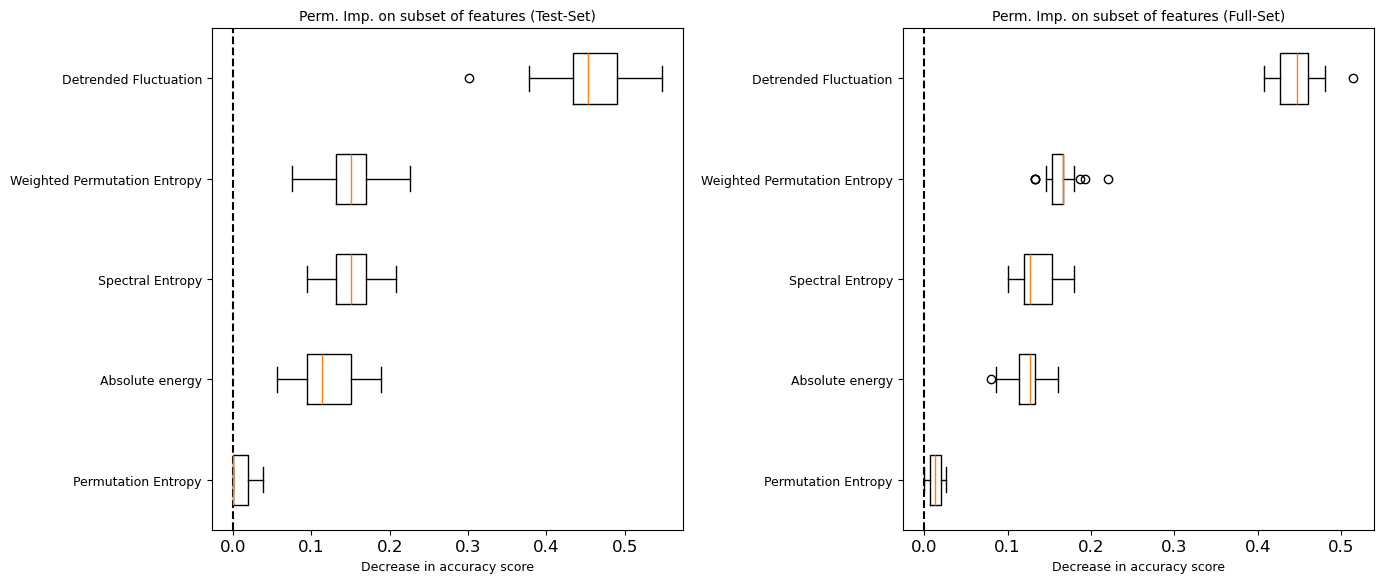

In [416]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14, 6))
# matplotlib.rcParams.update({'font.size': 12})

plot_permutation_importance(clf_sel, X_test_sel, y_test, selected_features_names_print, ax1)
ax1.set_title("Perm. Imp. on subset of features (Test-Set)",fontsize=10)
ax1.set_xlabel("Decrease in accuracy score", fontsize=9)
ax1.tick_params(axis='y', labelsize=9)
ax2.figure.tight_layout()

plot_permutation_importance(clf_sel, X_full, hir_labels, selected_features_names_print, ax2)
ax2.set_title("Perm. Imp. on subset of features (Full-Set)",fontsize=10)
ax2.set_xlabel("Decrease in accuracy score", fontsize=9)
ax2.tick_params(axis='y', labelsize=9)
ax2.figure.tight_layout()

plt.savefig(os.path.join(fig_save_path,'permuation_importance.svg'), dpi=300)
plt.show()

(150, 5)


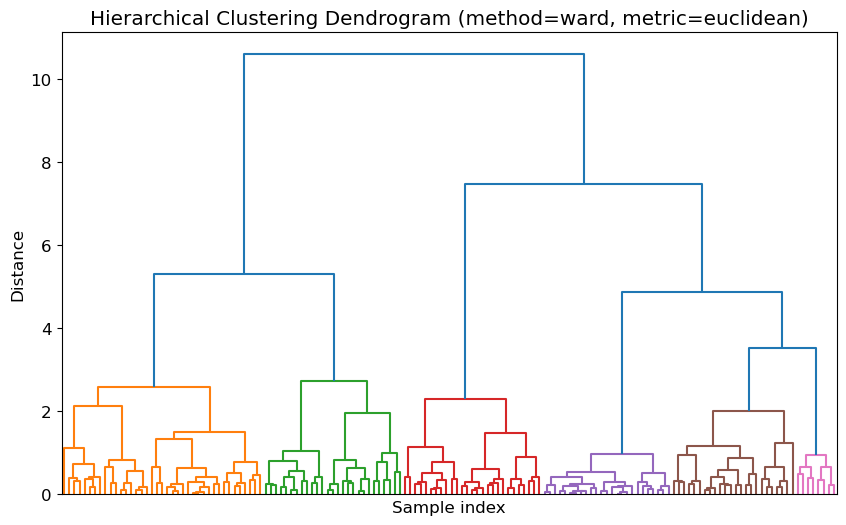

Total Labels:  150


In [ ]:
col_theshold = 3.5
dist_threshold = 3.5

selected_features_names_lst = selected_features_names.flatten().tolist()+['label']
selected_features_names_pnrtlst = selected_features_names_print.flatten().tolist()+['label']
rf_permc_features = spec_pointwise_metrics_df_copy[selected_features_names_lst].drop(columns=['label']).values
print(rf_permc_features.shape)

scaler = StandardScaler()
rf_permc_features= scaler.fit_transform(rf_permc_features)
rf_permc_features = normalize(rf_permc_features, norm='l2')

rfperc_linkage_matrix = perform_hierarchical_clustering(rf_permc_features,method='ward',metric='euclidean',
                                                        plot_dendrogram=True,color_threshold=col_theshold)
rf_permc_hir_labels = merge_clusters(rfperc_linkage_matrix, distance_threshold=dist_threshold)
print('Total Labels: ', len(rf_permc_hir_labels))

In [418]:
Counter(rf_permc_hir_labels)

Counter({np.int32(1): 39,
         np.int32(3): 27,
         np.int32(2): 27,
         np.int32(4): 25,
         np.int32(5): 24,
         np.int32(6): 8})

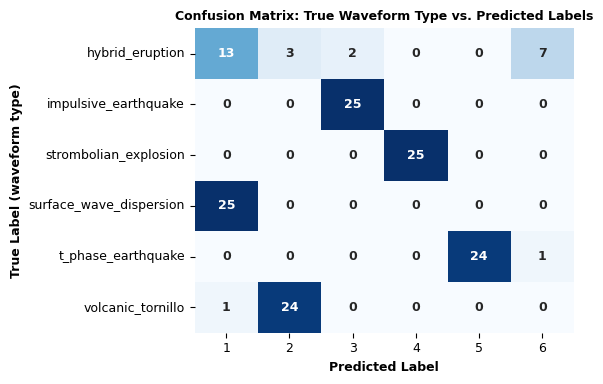

In [419]:
label_map = pd.DataFrame({'labels':rf_permc_hir_labels, 'waveform_type':['_'.join(name.split('_')[:-1]) for name in list_names]})
label_map.sort_values(by='labels',inplace=True)
label_map = label_map.reset_index(drop=True)

cm = pd.crosstab(label_map['waveform_type'], label_map['labels'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 9, 'fontweight':'bold'}, cbar=False)
plt.title('Confusion Matrix: True Waveform Type vs. Predicted Labels', fontsize=9, fontweight='bold')
plt.ylabel('True Label (waveform type)',fontsize=9, fontweight='bold')
plt.xlabel('Predicted Label',fontsize=9, fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path,'confusion_matrix_on_subset.svg'), dpi=300)
plt.show()

In [420]:
score = silhouette_score(rf_permc_features, rf_permc_hir_labels) #
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3820


### Plotting Decison Tree For Feature Interpretability

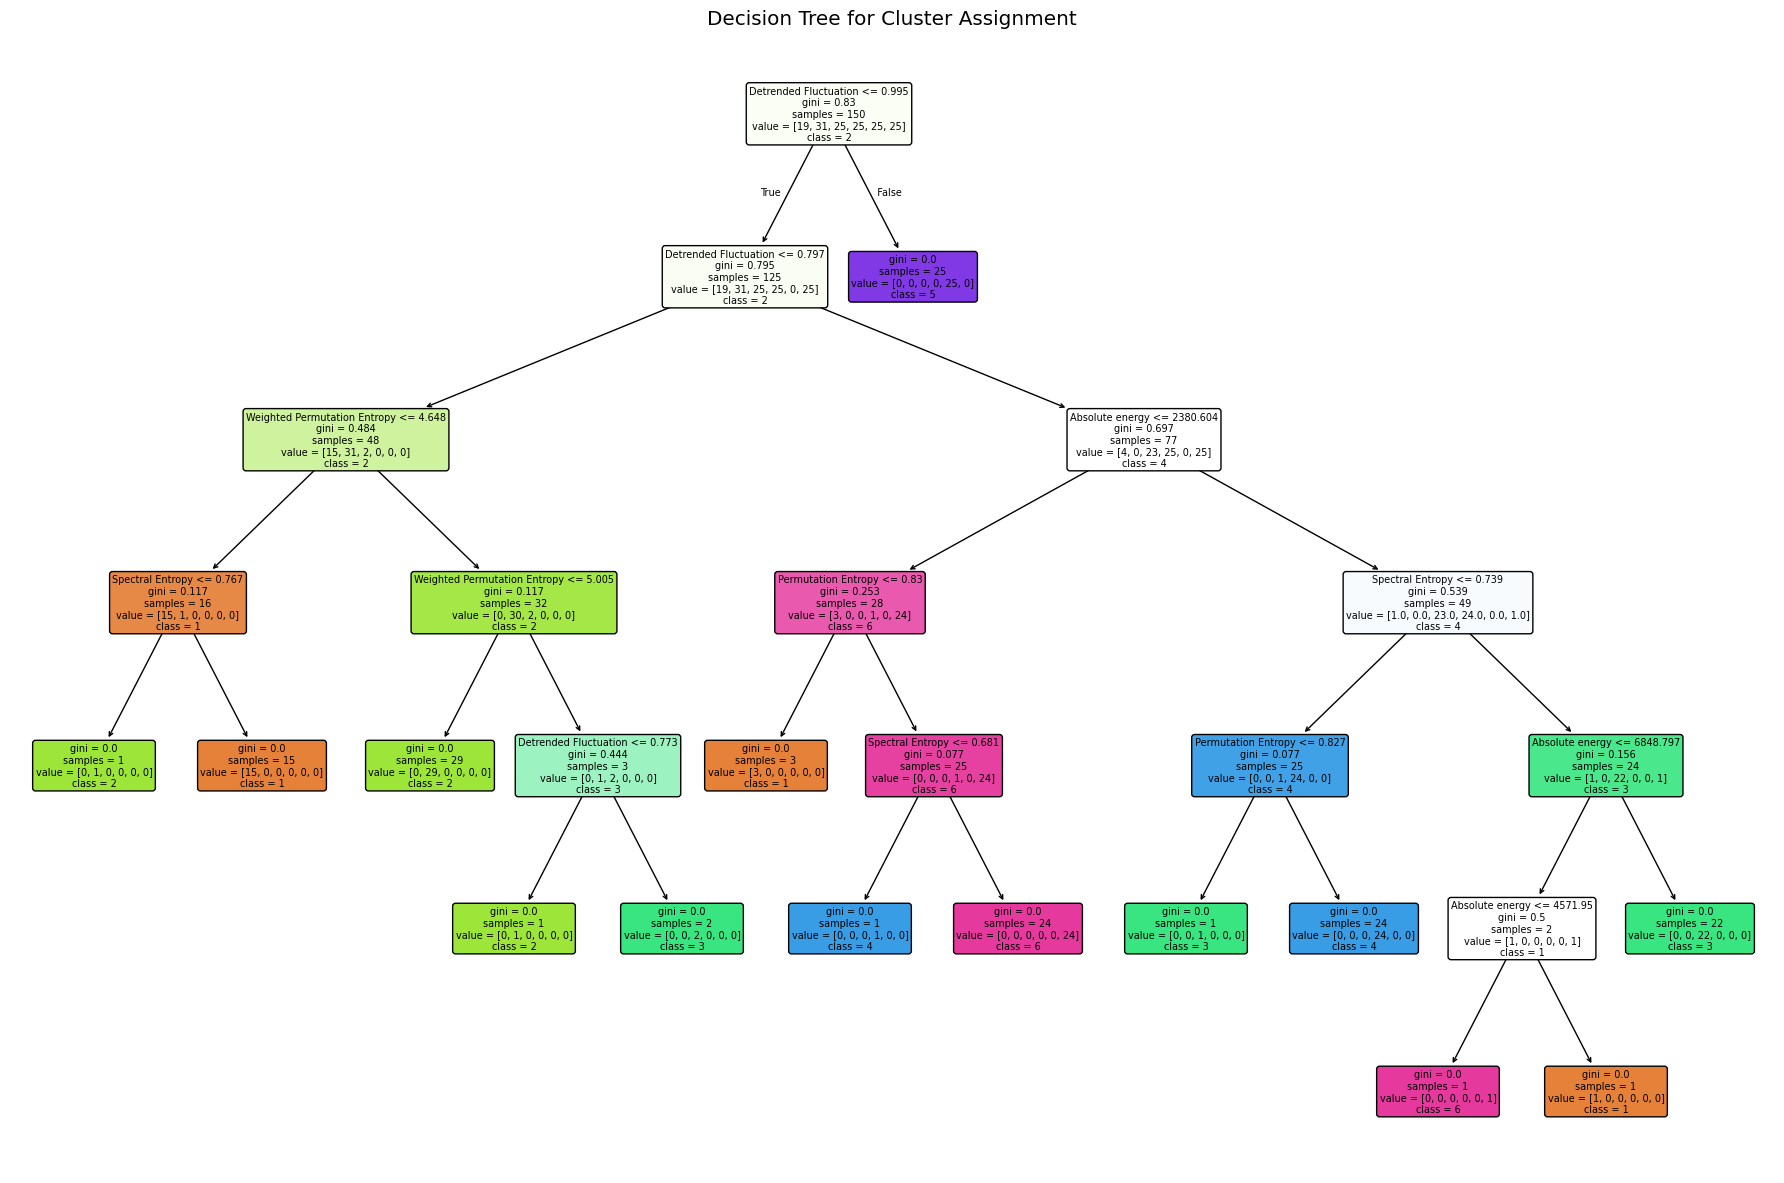

Decision Tree Rules:
 |--- Detrended Fluctuation <= 1.00
|   |--- Detrended Fluctuation <= 0.80
|   |   |--- Weighted Permutation Entropy <= 4.65
|   |   |   |--- Spectral Entropy <= 0.77
|   |   |   |   |--- class: 2
|   |   |   |--- Spectral Entropy >  0.77
|   |   |   |   |--- class: 1
|   |   |--- Weighted Permutation Entropy >  4.65
|   |   |   |--- Weighted Permutation Entropy <= 5.01
|   |   |   |   |--- class: 2
|   |   |   |--- Weighted Permutation Entropy >  5.01
|   |   |   |   |--- Detrended Fluctuation <= 0.77
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- Detrended Fluctuation >  0.77
|   |   |   |   |   |--- class: 3
|   |--- Detrended Fluctuation >  0.80
|   |   |--- Absolute energy <= 2380.60
|   |   |   |--- Permutation Entropy <= 0.83
|   |   |   |   |--- class: 1
|   |   |   |--- Permutation Entropy >  0.83
|   |   |   |   |--- Spectral Entropy <= 0.68
|   |   |   |   |   |--- class: 4
|   |   |   |   |--- Spectral Entropy >  0.68
|   |   |   |   |   |--- cl

In [369]:
selected_features_names_lst = selected_features_names.flatten().tolist()+['label']
selected_features_names_pnrtlst = selected_features_names_print.flatten().tolist()+['label']
rf_permc_dc_features = spec_pointwise_metrics_df_copy[selected_features_names_lst].drop(columns=['label']).values

# Fit Decision Tree
rf_permc_dcclf = DecisionTreeClassifier(max_depth=6, random_state=42)
rf_permc_dcclf.fit(rf_permc_dc_features, hir_labels)

# Visualize the tree structure
plt.figure(figsize=(18, 12))
plot_tree(rf_permc_dcclf, feature_names=selected_features_names_pnrtlst[:-1], class_names=[str(c) for c in np.unique(hir_labels)], filled=True, rounded=True, fontsize=7)
plt.title('Decision Tree for Cluster Assignment')
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path,'decision_tree_on_subset.svg'), dpi=300)
plt.show()

# Print top rules
from sklearn.tree import export_text
rf_permc_dc_rules = export_text(rf_permc_dcclf, feature_names=selected_features_names_pnrtlst[:-1])
print('Decision Tree Rules:\n', rf_permc_dc_rules)

### Bootstrapped Feature Importance Method
- Answers if I remove a feature how much geometrical structure changes for the cluster

                                   feature  mean_importance  std_importance
0              permutation_entropy_antropy         0.156393        0.060377
1                 spectral_entropy_antropy         0.138003        0.056794
2                      svd_entropy_antropy         0.120391        0.052221
3                  hjorth_mobility_antropy         0.111365        0.051986
4                hjorth_complexity_antropy         0.104597        0.048689
5                     petrosian_fd_antropy         0.093236        0.043313
6                       higuchi_fd_antropy         0.084692        0.044677
7            detrended_fluctuation_antropy         0.079089        0.042262
8     normalized_permutation_entropy_ordpy         0.070435        0.043087
9     statistical_complexity_entropy_ordpy         0.066889        0.042892
10                    fisher_shannon_ordpy         0.059448        0.042708
11               global_node_entropy_ordpy         0.057024        0.044627
12          

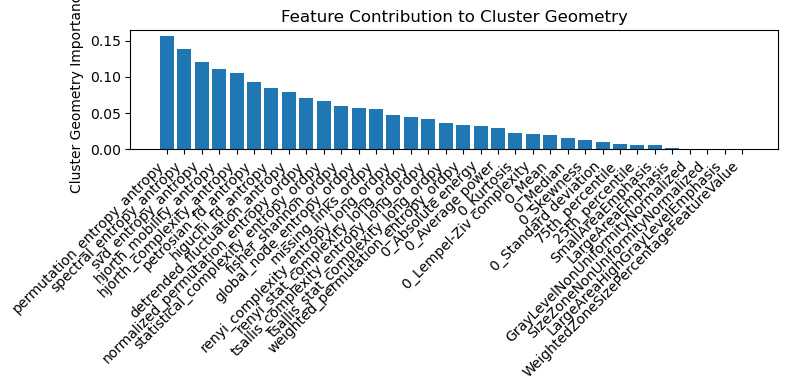

In [300]:
def full_hierarchical_cluster(X, distance_threshold=2.5):
    dist = pdist(X, metric='euclidean')
    Z = linkage(dist, method='ward', optimal_ordering=True)
    labels = fcluster(Z, t=distance_threshold, criterion='distance')
    return labels

def feature_removal_importance(X_raw, base_labels, feature_cols, threshold=2.5):
    importance_scores = []

    for j in range(X_raw.shape[1]):
        X_reduced = np.delete(X_raw, j, axis=1)

        X_norm_reduced = prepare_for_clustering(X_reduced)
        new_labels = full_hierarchical_cluster(X_norm_reduced, threshold)

        ari = adjusted_rand_score(base_labels, new_labels)
        importance_scores.append(1 - ari)  # higher = more important

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "geometry_importance_removal": importance_scores
    }).sort_values("geometry_importance_removal", ascending=False)

    return importance_df

def bootstrap_geometry_importance(X_raw, feature_cols,
                                  threshold=2.5, n_boot=30):

    all_importances = []

    for _ in range(n_boot):
        idx = np.random.choice(len(X_raw), len(X_raw), replace=True)
        X_boot = X_raw[idx]

        X_norm_boot = prepare_for_clustering(X_boot)
        base_labels_boot = full_hierarchical_cluster(X_norm_boot, threshold)

        imp_df = feature_removal_importance(
            X_boot, base_labels_boot, feature_cols, threshold
        )

        all_importances.append(
            imp_df["geometry_importance_removal"].values
        )

    all_importances = np.array(all_importances)

    mean_importance = np.mean(all_importances, axis=0)
    std_importance = np.std(all_importances, axis=0)

    bootstrap_df = pd.DataFrame({
        "feature": feature_cols,
        "mean_importance": mean_importance,
        "std_importance": std_importance
    }).sort_values("mean_importance", ascending=False)

    return bootstrap_df

def prepare_for_clustering(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_norm = normalize(X_scaled, norm='l2')
    return X_norm

feature_cols = list(spec_pointwise_metrics_df_copy.drop(columns=['label']).columns)
X_raw = spec_pointwise_metrics_df_copy[feature_cols].values
X_norm = prepare_for_clustering(X_raw)
base_labels = full_hierarchical_cluster(X_norm, distance_threshold=3.5)
bootstrap_df = bootstrap_geometry_importance(X_raw, feature_names)
#print(bootstrap_df)

plt.figure(figsize=(8,4))
plt.bar(bootstrap_df["feature"], bootstrap_df["mean_importance"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cluster Geometry Importance")
plt.title("Feature Contribution to Cluster Geometry")
plt.tight_layout()
plt.show()

### Test Codes

In [ ]:
# Group by 'hir_label' and compute mean for all columns except 'label'
#spec_pointwise_metrics_df_hirlabeled.drop(columns=['label']).groupby(by='hir_label').mean()